# NLPCSS-20 Sequence Pattern Analysis

This notebook analyses sequential patterns of predicted argumentative-unit types in the final filtered NLPCSS-20 predictions. Sequence patterns are based on assumption, testimony, anecdote, and statistics, while the residual `other` category is excluded. Consecutive occurrences of the same argumentative-unit type are collapsed into a single sequence element.

## 1. Load Final Predictions

In [2]:
from pathlib import Path
import pandas as pd

PREDICTIONS_PATH = Path(
    "../results/model_predictions/nlpcss20_model_predictions_filtered_no_one_word.csv"
)

df = pd.read_csv(PREDICTIONS_PATH)

df = df[df["topics"].notna()].copy()

df.shape

(400661, 23)

In [4]:
df.columns.tolist()

['article_position',
 'original_index',
 'event_id',
 'source',
 'title',
 'adfontes_fair',
 'adfontes_political',
 'allsides_bias',
 'time',
 'topics',
 'author',
 'word_count',
 'span_id',
 'span_start',
 'span_end',
 'label',
 'confidence',
 'prob_anecdote',
 'prob_testimony',
 'prob_assumption',
 'prob_statistics',
 'prob_other',
 'text']

## 2. Construct Argumentative-Unit Sequences

In [5]:
LABEL_MAP = {
    "assumption": "AS",
    "testimony": "TE",
    "anecdote": "AN",
    "statistics": "ST",
}

sequence_spans = (
    df.loc[
        df["label"].isin(LABEL_MAP),
        ["article_position", "span_id", "span_start", "span_end", "label"],
    ]
    .assign(sequence_label=lambda x: x["label"].map(LABEL_MAP))
    .sort_values(
        ["article_position", "span_start", "span_end", "span_id"]
    )
    .reset_index(drop=True)
)

sequence_spans.head(10)

,article_position,span_id,span_start,span_end,label,sequence_label
0,1,2,40,62,assumption,AS
1,1,5,92,101,assumption,AS
2,1,8,186,324,testimony,TE
3,1,9,324,434,anecdote,AN
4,1,10,437,628,testimony,TE
5,1,11,628,731,testimony,TE
6,1,12,736,848,assumption,AS
7,1,13,849,933,anecdote,AN
8,1,16,942,1042,testimony,TE
9,1,18,1044,1059,testimony,TE


In [6]:
def collapse_consecutive(labels):
    collapsed = []

    for label in labels:
        if not collapsed or label != collapsed[-1]:
            collapsed.append(label)

    return collapsed


article_sequences = (
    sequence_spans
    .groupby("article_position")["sequence_label"]
    .agg(list)
    .reset_index(name="raw_sequence")
)

article_sequences["change_flow"] = (
    article_sequences["raw_sequence"]
    .apply(collapse_consecutive)
)

article_sequences.head()

,article_position,raw_sequence,change_flow
0,1,"[AS, AS, TE, AN, TE, TE, AS, AN, TE, TE, AN, T...","[AS, TE, AN, TE, AS, AN, TE, AN, TE, AS, TE, A..."
1,2,"[AS, TE, TE, TE, TE, TE, AS, AS, TE, AS, TE, T...","[AS, TE, AS, TE, AS, TE, AS]"
2,3,"[TE, TE, TE, AS, TE, TE, TE, AN, AN, AS, AN, A...","[TE, AS, TE, AN, AS, AN, AS, TE]"
3,4,"[AS, TE, TE, AS, TE, AS, AN, AN, AS, TE]","[AS, TE, AS, TE, AS, AN, AS, TE]"
4,5,"[AS, AN, AS, AS, AS, AN, AN, TE, AS, AS, AS, T...","[AS, AN, AS, AN, TE, AS, TE, AS, TE, AS, TE, A..."


In [7]:
sequence_coverage = pd.DataFrame(
    {
        "total_articles": [df["article_position"].nunique()],
        "articles_with_sequence": [article_sequences["article_position"].nunique()],
    }
)

sequence_coverage["articles_without_sequence"] = (
    sequence_coverage["total_articles"]
    - sequence_coverage["articles_with_sequence"]
)

sequence_coverage

,total_articles,articles_with_sequence,articles_without_sequence
0,7616,7616,0


In [8]:
# sequence-lenght distribution before an dafter collapsing consecutive identical labels
article_sequences["raw_length"] = (
    article_sequences["raw_sequence"].str.len()
)

article_sequences["flow_length"] = (
    article_sequences["change_flow"].str.len()
)

article_sequences[
    ["raw_length", "flow_length"]
].describe().round(2)

,raw_length,flow_length
count,7616.00,7616.00
mean,51.98,23.72
std,36.28,16.83
min,1.00,1.00
25%,28.00,13.00
50%,46.00,21.00
75%,67.00,31.00
max,547.00,268.00


## 3. Overall Sequence Patterns

In [9]:
article_sequences["flow"] = article_sequences["change_flow"].apply(tuple)

flow_frequency = (
    article_sequences["flow"]
    .value_counts()
    .rename_axis("flow")
    .reset_index(name="articles")
)

flow_frequency["percentage"] = (
    flow_frequency["articles"]
    / len(article_sequences)
    * 100
)

flow_frequency.head(15).round(2)

,flow,articles,percentage
0,"(AS,)",31,0.41
1,"(AS, AN, AS)",23,0.30
2,"(AS, AN, AS, AN, AS)",16,0.21
3,"(AN, AS)",16,0.21
4,"(TE, AS, TE)",16,0.21
5,"(AS, TE, AS, TE)",16,0.21
6,"(AS, TE)",15,0.20
7,"(AS, TE, AS)",14,0.18
8,"(TE,)",11,0.14
9,"(AS, TE, AS, TE, AS, TE)",10,0.13


In [10]:
flow_sparsity = pd.DataFrame(
    {
        "unique_flows": [flow_frequency["flow"].nunique()],
        "singleton_flows": [(flow_frequency["articles"] == 1).sum()],
        "articles_in_top_15": [flow_frequency.head(15)["articles"].sum()],
    }
)

flow_sparsity["top_15_coverage_percentage"] = (
    flow_sparsity["articles_in_top_15"]
    / len(article_sequences)
    * 100
)

flow_sparsity

,unique_flows,singleton_flows,articles_in_top_15,top_15_coverage_percentage
0,7019,6771,210,2.757353


## 4. Argumentative-Unit Transition Patterns

In [11]:
transition_records = []

for row in article_sequences.itertuples(index=False):
    for first, second in zip(
        row.change_flow,
        row.change_flow[1:],
    ):
        transition_records.append(
            {
                "article_position": row.article_position,
                "from_label": first,
                "to_label": second,
            }
        )

transitions_df = pd.DataFrame(transition_records)

transition_frequency = (
    transitions_df
    .groupby(["from_label", "to_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

transition_frequency["percentage"] = (
    transition_frequency["count"]
    / len(transitions_df)
    * 100
)

transition_frequency.round(2)

,from_label,to_label,count,percentage
10,TE,AS,30405,17.57
5,AS,TE,30376,17.56
3,AS,AN,28236,16.32
0,AN,AS,26959,15.58
2,AN,TE,22433,12.97
9,TE,AN,20720,11.98
4,AS,ST,4034,2.33
7,ST,AS,3747,2.17
8,ST,TE,1645,0.95
11,TE,ST,1528,0.88


In [12]:
transition_matrix = (
    transitions_df
    .groupby(["from_label", "to_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=["AS", "TE", "AN", "ST"],
        columns=["AS", "TE", "AN", "ST"],
        fill_value=0,
    )
)

transition_matrix

to_label,AS,TE,AN,ST
from_label,,,,
AS,0,30376,28236,4034
TE,30405,0,20720,1528
AN,26959,22433,0,1427
ST,3747,1645,1493,0


In [13]:
transition_percentage_matrix = (
    transition_matrix
    .div(transition_matrix.sum(axis=1), axis=0)
    * 100
)

transition_percentage_matrix.round(2)

to_label,AS,TE,AN,ST
from_label,,,,
AS,0.00,48.49,45.07,6.44
TE,57.75,0.00,39.35,2.90
AN,53.05,44.14,0.00,2.81
ST,54.42,23.89,21.68,0.00


### 4.1 Overall Transition Matrix

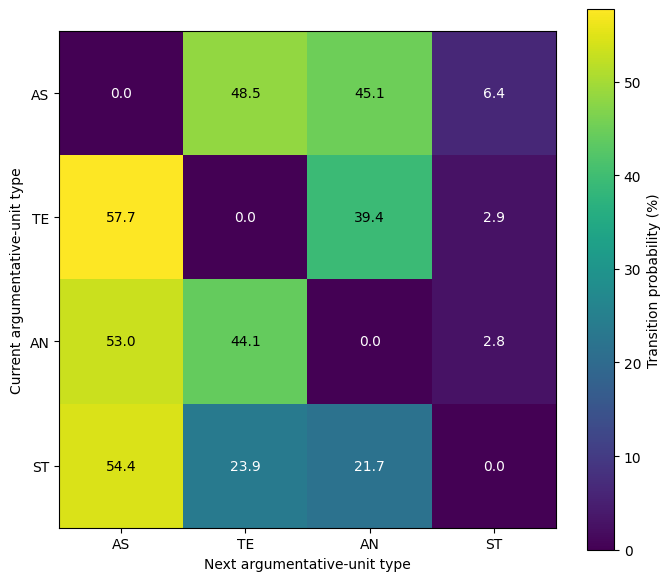

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    transition_percentage_matrix.values,
    cmap="viridis",
)

ax.set_xticks(range(4))
ax.set_xticklabels(["AS", "TE", "AN", "ST"])

ax.set_yticks(range(4))
ax.set_yticklabels(["AS", "TE", "AN", "ST"])

ax.set_xlabel("Next argumentative-unit type")
ax.set_ylabel("Current argumentative-unit type")

for i in range(4):
    for j in range(4):
        value = transition_percentage_matrix.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            color="black" if value > 25 else "white",
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Transition probability (%)")

plt.tight_layout()

plt.savefig(
    "../figures/nlpcss20_overall_transition_matrix.pdf",
    bbox_inches="tight",
)

plt.show()

The overall transition matrix shows that most argumentative-unit changes occur among assumption, testimony, and anecdote. Testimony is most often followed by assumption, while anecdote and statistics also transition most frequently to assumption. Assumption itself is followed primarily by testimony or anecdote, with transitions to statistics occurring much less often. This suggests that assumption occupies a central position in the predicted argumentative-unit sequences, frequently alternating with evidence-oriented categories rather than appearing as an isolated type.

## 5. Sequence Patterns by Political Orientation

In [15]:
article_metadata = (
    df.drop_duplicates("article_position")
    .set_index("article_position")[
        ["allsides_bias", "topics", "source"]
    ]
)

article_sequences = (
    article_sequences
    .set_index("article_position")
    .join(article_metadata)
    .reset_index()
)

article_sequences.head()

,article_position,raw_sequence,change_flow,raw_length,flow_length,flow,allsides_bias,topics,source
0,1,"[AS, AS, TE, AN, TE, TE, AS, AN, TE, TE, AN, T...","[AS, TE, AN, TE, AS, AN, TE, AN, TE, AS, TE, A...",48,28,"(AS, TE, AN, TE, AS, AN, TE, AN, TE, AS, TE, A...",From the Right,Election: Presidential,Fox News
1,2,"[AS, TE, TE, TE, TE, TE, AS, AS, TE, AS, TE, T...","[AS, TE, AS, TE, AS, TE, AS]",18,7,"(AS, TE, AS, TE, AS, TE, AS)",From the Center,Election: Presidential,USA TODAY
2,3,"[TE, TE, TE, AS, TE, TE, TE, AN, AN, AS, AN, A...","[TE, AS, TE, AN, AS, AN, AS, TE]",23,8,"(TE, AS, TE, AN, AS, AN, AS, TE)",From the Right,White House,Washington Times
3,4,"[AS, TE, TE, AS, TE, AS, AN, AN, AS, TE]","[AS, TE, AS, TE, AS, AN, AS, TE]",10,8,"(AS, TE, AS, TE, AS, AN, AS, TE)",From the Right,"White House, Politics",Washington Times
4,5,"[AS, AN, AS, AS, AS, AN, AN, TE, AS, AS, AS, T...","[AS, AN, AS, AN, TE, AS, TE, AS, TE, AS, TE, A...",90,34,"(AS, AN, AS, AN, TE, AS, TE, AS, TE, AS, TE, A...",From the Center,"White House, Politics",BBC News


In [16]:
transitions_df = transitions_df.merge(
    article_sequences[
        ["article_position", "allsides_bias"]
    ],
    on="article_position",
    how="left",
)

transitions_df.head()

,article_position,from_label,to_label,allsides_bias
0,1,AS,TE,From the Right
1,1,TE,AN,From the Right
2,1,AN,TE,From the Right
3,1,TE,AS,From the Right
4,1,AS,AN,From the Right


In [17]:
def make_transition_percentage_matrix(data):
    matrix = (
        data.groupby(["from_label", "to_label"])
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=["AS", "TE", "AN", "ST"],
            columns=["AS", "TE", "AN", "ST"],
            fill_value=0,
        )
    )

    return matrix.div(matrix.sum(axis=1), axis=0) * 100


orientation_transition_matrices = {
    orientation: make_transition_percentage_matrix(
        transitions_df[
            transitions_df["allsides_bias"] == orientation
        ]
    )
    for orientation in [
        "From the Center",
        "From the Left",
        "From the Right",
    ]
}

pd.concat(
    orientation_transition_matrices,
    names=["orientation", "from_label"],
).round(2)

to_label                       AS     TE     AN    ST
orientation     from_label                           
From the Center AS           0.00  48.36  45.62  6.02
                TE          53.68   0.00  42.75  3.56
                AN          50.84  46.51   0.00  2.65
                ST          47.35  29.40  23.26  0.00
From the Left   AS           0.00  47.91  45.70  6.40
                TE          59.05   0.00  38.41  2.55
                AN          53.69  43.53   0.00  2.78
                ST          56.56  22.04  21.39  0.00
From the Right  AS           0.00  49.65  43.61  6.74
                TE          57.56   0.00  39.24  3.20
                AN          53.07  43.97   0.00  2.96
                ST          54.29  24.32  21.39  0.00

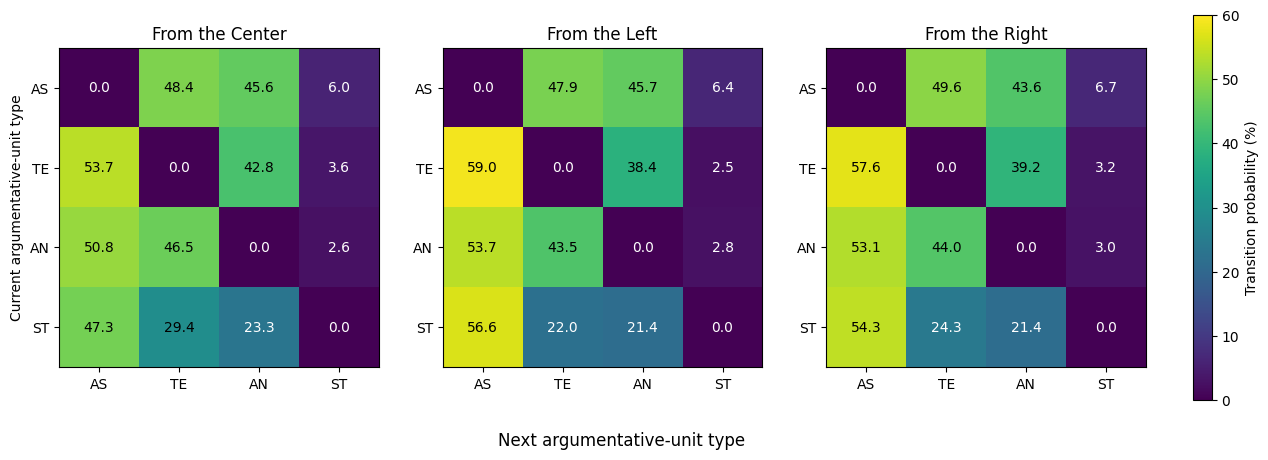

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

orientations = [
    "From the Center",
    "From the Left",
    "From the Right",
]

for ax, orientation in zip(axes, orientations):
    matrix = orientation_transition_matrices[orientation]

    image = ax.imshow(
        matrix.values,
        cmap="viridis",
        vmin=0,
        vmax=60,
    )

    ax.set_xticks(range(4))
    ax.set_xticklabels(["AS", "TE", "AN", "ST"])

    ax.set_yticks(range(4))
    ax.set_yticklabels(["AS", "TE", "AN", "ST"])

    ax.set_title(orientation)

    for i in range(4):
        for j in range(4):
            value = matrix.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                color="black" if value > 25 else "white",
            )

axes[0].set_ylabel("Current argumentative-unit type")

fig.supxlabel("Next argumentative-unit type")

colorbar = fig.colorbar(
    image,
    ax=axes,
    fraction=0.025,
    pad=0.04,
)
colorbar.set_label("Transition probability (%)")

plt.savefig(
    "../figures/nlpcss20_transition_matrices_by_orientation.pdf",
    bbox_inches="tight",
)

plt.show()

The transition structure is broadly similar across political orientations. In all three groups, assumption, testimony, and anecdote form the dominant transition network, while transitions involving statistics are comparatively infrequent. Some differences are nevertheless visible: testimony is followed by assumption more often in Left and Right articles than in Center articles, whereas Center articles show a somewhat higher probability of testimony being followed by anecdote. Overall, these patterns suggest that political orientation is associated with modest differences in argumentative-unit ordering rather than fundamentally different sequence structures.

### 5.1 Starting and Ending Argumentative-Unit Types

In [19]:
article_sequences["start_label"] = (
    article_sequences["change_flow"].str[0]
)

article_sequences["end_label"] = (
    article_sequences["change_flow"].str[-1]
)

start_by_orientation = (
    pd.crosstab(
        article_sequences["allsides_bias"],
        article_sequences["start_label"],
        normalize="index",
    )
    * 100
)

end_by_orientation = (
    pd.crosstab(
        article_sequences["allsides_bias"],
        article_sequences["end_label"],
        normalize="index",
    )
    * 100
)

start_by_orientation.round(2), end_by_orientation.round(2)

(start_label         AN     AS    ST     TE
 allsides_bias                             
 From the Center  33.06  49.75  1.07  16.12
 From the Left    31.89  52.97  1.61  13.53
 From the Right   30.86  52.29  1.57  15.29,
 end_label           AN     AS    ST     TE
 allsides_bias                             
 From the Center  29.59  26.78  2.73  40.91
 From the Left    25.29  33.08  2.63  38.99
 From the Right   27.64  33.00  3.25  36.11)

Across political orientations, assumption is the most common starting argumentative-unit type, accounting for roughly half of article openings, followed by anecdote. Testimony is less common as an opening type, while statistics rarely begins an argumentative-unit sequence. In contrast, testimony is the most common ending type across all three orientations. Center articles end with testimony somewhat more frequently, whereas Left and Right articles show a somewhat higher proportion of assumption endings. Overall, the starting and ending distributions are broadly similar across orientations, with only modest differences in how argumentative sequences are framed at their boundaries.

## 6. Sequence Patterns by Topic

In [20]:
topic_counts = (
    article_sequences["topics"]
    .value_counts()
)

retained_topics = topic_counts[
    topic_counts >= 100
].index

len(retained_topics)

17

In [21]:
topic_transitions = transitions_df.merge(
    article_sequences[
        ["article_position", "topics"]
    ],
    on="article_position",
    how="left",
)

topic_transitions = topic_transitions[
    topic_transitions["topics"].isin(retained_topics)
]

topic_transitions.head()

,article_position,from_label,to_label,allsides_bias,topics
0,1,AS,TE,From the Right,Election: Presidential
1,1,TE,AN,From the Right,Election: Presidential
2,1,AN,TE,From the Right,Election: Presidential
3,1,TE,AS,From the Right,Election: Presidential
4,1,AS,AN,From the Right,Election: Presidential


In [22]:
topic_transition_matrices = {
    topic: make_transition_percentage_matrix(
        topic_transitions[
            topic_transitions["topics"] == topic
        ]
    )
    for topic in retained_topics
}

len(topic_transition_matrices)

17

In [23]:
topic_transition_summary = pd.DataFrame(
    {
        topic: {
            f"{from_label} → {to_label}":
                matrix.loc[from_label, to_label]
            for from_label in ["AS", "TE", "AN", "ST"]
            for to_label in ["AS", "TE", "AN", "ST"]
            if from_label != to_label
        }
        for topic, matrix in topic_transition_matrices.items()
    }
).T

topic_transition_summary = topic_transition_summary.loc[
    retained_topics
]

topic_transition_summary.round(2)

,AS → TE,AS → AN,AS → ST,TE → AS,TE → AN,TE → ST,AN → AS,AN → TE,AN → ST,ST → AS,ST → TE,ST → AN
topics,,,,,,,,,,,,
Election: Presidential,45.56,41.89,12.54,63.00,32.47,4.53,57.76,37.03,5.21,62.63,17.09,20.28
Politics,49.99,46.75,3.26,56.48,41.91,1.60,51.70,46.23,2.07,47.69,24.20,28.11
White House,52.73,43.85,3.42,62.00,35.65,2.35,54.55,43.45,1.99,45.93,30.37,23.70
Immigration,56.62,39.16,4.22,62.84,34.98,2.18,54.09,43.40,2.52,44.88,30.73,24.39
Middle East,55.18,42.60,2.21,57.33,40.13,2.55,51.69,46.33,1.98,32.93,39.63,27.44
Elections,36.87,53.35,9.78,61.38,34.39,4.23,64.10,31.12,4.78,61.40,17.25,21.35
Healthcare,56.48,35.83,7.69,69.75,24.35,5.90,57.89,38.53,3.57,54.75,33.84,11.41
US Senate,48.01,48.47,3.52,67.79,30.29,1.92,64.96,33.31,1.73,48.15,26.85,25.00
World,47.25,49.74,3.00,50.19,47.60,2.21,46.93,51.39,1.68,36.70,37.61,25.69


### 6.1 Topic Transition Patterns

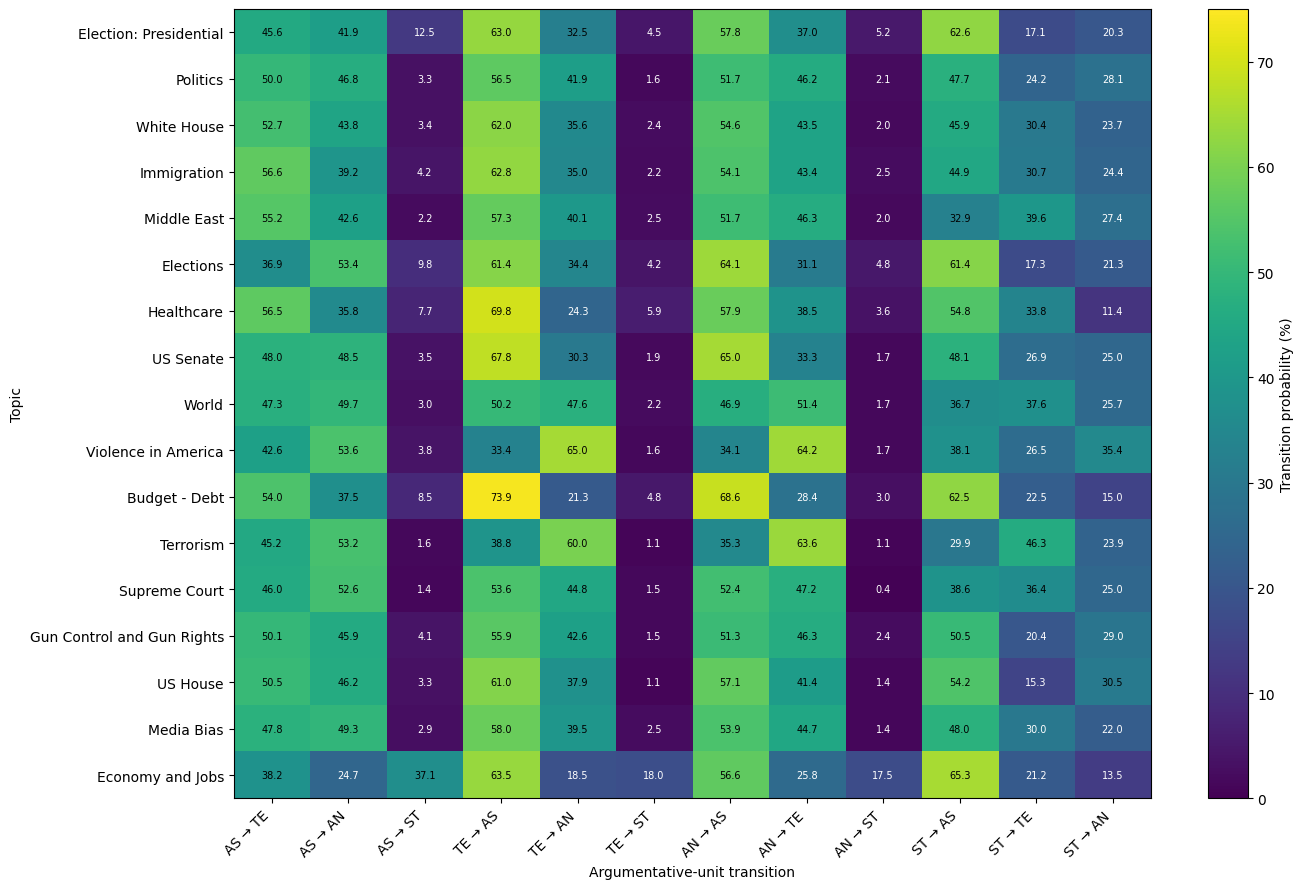

In [24]:
fig, ax = plt.subplots(figsize=(14, 9))

image = ax.imshow(
    topic_transition_summary.values,
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=75,
)

ax.set_xticks(range(len(topic_transition_summary.columns)))
ax.set_xticklabels(
    topic_transition_summary.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(range(len(topic_transition_summary.index)))
ax.set_yticklabels(topic_transition_summary.index)

ax.set_xlabel("Argumentative-unit transition")
ax.set_ylabel("Topic")

for i in range(len(topic_transition_summary.index)):
    for j in range(len(topic_transition_summary.columns)):
        value = topic_transition_summary.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            color="black" if value > 30 else "white",
            fontsize=7,
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Transition probability (%)")

plt.tight_layout()

plt.savefig(
    "../figures/nlpcss20_topic_transition_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

Across topics, transition patterns are dominated by movement among assumption, testimony, and anecdote, while transitions involving statistics remain comparatively rare. A common pattern across many topics is the strong tendency for testimony and anecdote to be followed by assumption, suggesting that assumption often functions as a central connective or interpretive unit within argumentative flow. Topic-specific variation is nevertheless visible. Economy and Jobs and Budget - Debt show relatively higher shares of transitions involving statistics, while topics such as Violence in America and Terrorism display stronger testimony- and anecdote-oriented movement. Overall, the heatmap suggests that sequence structure varies by topic, but that this variation mainly concerns the balance among the three dominant unit types rather than a general reorganization of all transition possibilities.

## 7. Statistical Comparison of Transition Patterns

To assess whether argumentative-unit transition patterns differ across political orientations, transition shares are compared at the outlet level. Using outlets rather than individual articles as the primary observations reduces the dependence introduced by articles being nested within news sources. Each article is represented by the relative frequency of the 12 possible directed transitions among assumption, testimony, anecdote, and statistics, after consecutive repetitions have been collapsed.

In [25]:
label_order = ["AS", "TE", "AN", "ST"]

transition_pairs = [
    f"{first} → {second}"
    for first in label_order
    for second in label_order
    if first != second
]

article_transition_counts = (
    transitions_df
    .assign(
        transition=lambda x:
        x["from_label"] + " → " + x["to_label"]
    )
    .groupby(["article_position", "transition"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=transition_pairs, fill_value=0)
    .reindex(
        article_sequences["article_position"],
        fill_value=0,
    )
)

article_transition_counts["total_transitions"] = (
    article_transition_counts[transition_pairs].sum(axis=1)
)

(article_transition_counts["total_transitions"] == 0).sum()

np.int64(46)

That means 47 articles have no change transition at all after collapsing consecutive identical labels. Ttheir collapsed sequence contains only one argumentative-unit type, such as (AS,), so a transition share cannot be calculated for them.

In [26]:
article_transition_shares = (
    article_transition_counts.loc[
        article_transition_counts["total_transitions"] > 0,
        transition_pairs
    ]
    .div(
        article_transition_counts.loc[
            article_transition_counts["total_transitions"] > 0,
            "total_transitions"
        ],
        axis=0,
    )
)

article_transition_shares.shape

(7570, 12)

In [27]:
article_transition_shares = (
    article_transition_shares
    .join(
        article_sequences
        .set_index("article_position")[["source", "allsides_bias"]]
    )
)

article_transition_shares.head()

,AS → TE,AS → AN,AS → ST,TE → AS,TE → AN,TE → ST,AN → AS,AN → TE,AN → ST,ST → AS,ST → TE,ST → AN,source,allsides_bias
article_position,,,,,,,,,,,,,,
1,0.148148,0.222222,0.0,0.185185,0.074074,0.037037,0.148148,0.148148,0.0,0.0,0.037037,0.0,Fox News,From the Right
2,0.500000,0.000000,0.0,0.500000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,USA TODAY,From the Center
3,0.285714,0.142857,0.0,0.142857,0.142857,0.000000,0.285714,0.000000,0.0,0.0,0.000000,0.0,Washington Times,From the Right
4,0.428571,0.142857,0.0,0.285714,0.000000,0.000000,0.142857,0.000000,0.0,0.0,0.000000,0.0,Washington Times,From the Right
5,0.242424,0.151515,0.0,0.272727,0.090909,0.000000,0.121212,0.121212,0.0,0.0,0.000000,0.0,BBC News,From the Center


In [28]:
retained_sources = (
    article_sequences["source"]
    .value_counts()
    .loc[lambda x: x >= 50]
    .index
)

outlet_transition_shares = (
    article_transition_shares[
        article_transition_shares["source"].isin(retained_sources)
    ]
    .groupby(["source", "allsides_bias"])[transition_pairs]
    .mean()
    .reset_index()
)

outlet_transition_shares.groupby("allsides_bias").size()

allsides_bias
From the Center     6
From the Left      12
From the Right      9
dtype: int64

In [29]:
# Kruskal-Wallis test for each transition + Holm correction across them
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

orientation_order = [
    "From the Center",
    "From the Left",
    "From the Right",
]

results = []

for transition in transition_pairs:
    groups = [
        outlet_transition_shares.loc[
            outlet_transition_shares["allsides_bias"] == orientation,
            transition,
        ]
        for orientation in orientation_order
    ]

    h_stat, p_value = kruskal(*groups)

    n = len(outlet_transition_shares)
    k = len(orientation_order)
    epsilon_squared = max(0, (h_stat - k + 1) / (n - k))

    results.append({
        "transition": transition,
        "H": h_stat,
        "p_value": p_value,
        "epsilon_squared": epsilon_squared,
    })

transition_test_results = pd.DataFrame(results)

transition_test_results["p_holm"] = multipletests(
    transition_test_results["p_value"],
    method="holm",
)[1]

transition_test_results.round(4)

,transition,H,p_value,epsilon_squared,p_holm
0,AS → TE,1.7954,0.4075,0.0000,1.0
1,AS → AN,2.1605,0.3395,0.0067,1.0
2,AS → ST,3.8373,0.1468,0.0766,1.0
3,TE → AS,2.0714,0.3550,0.0030,1.0
4,TE → AN,3.2716,0.1948,0.0530,1.0
5,TE → ST,1.8166,0.4032,0.0000,1.0
6,AN → AS,0.3629,0.8341,0.0000,1.0
7,AN → TE,1.8867,0.3893,0.0000,1.0
8,AN → ST,0.0560,0.9724,0.0000,1.0
9,ST → AS,4.8470,0.0886,0.1186,1.0


The outlet statistical comparison provided no evidence that argumentative-unit transition patterns differed systematically across political orientations. None of the 12 directed transitions showed a statistically significant difference between Center, Left, and Right outlets, and all tests remained non-significant after Holm correction. Effect sizes were generally small or negligible. The largest estimated differences occurred for transitions from statistics to assumption and from assumption to statistics, but these effects were not statistically significant. Consequently, no post-hoc pairwise comparisons were conducted. These results suggest that the modest orientation differences visible in the descriptive transition matrices are not robust when variation between news outlets is taken into account.

In [30]:
# saving results
transition_test_results.to_csv(
    "../results/nlpcss20_sequence_statistical_tests.csv",
    index=False,
)